In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import nltk

nltk.download('vader_lexicon')
nltk.download('stopwords')

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


APPS_FILE = "googleplaystore.csv"
REVIEWS_FILE = "googleplaystore_user_reviews.csv"

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/b47d5317-d063-4e78-85a3-
[nltk_data]     bac64aba1ffc/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/b47d5317-d063-4e78-85a3-
[nltk_data]     bac64aba1ffc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# STEP 1: DATA LOADING & FILTERING (M1)

apps = pd.read_csv(APPS_FILE)
print("Apps shape:", apps.shape)
print(apps.head())

# Standardize column names for safety
apps.columns = [c.strip().replace(" ", "_") for c in apps.columns]

# Filter to Health & Fitness category
health_apps = apps[apps["Category"].str.upper().str.contains("HEALTH", na=False)]
print("Health-related apps:", health_apps.shape[0])

# Load user reviews
reviews = pd.read_csv(REVIEWS_FILE)
print("Reviews shape:", reviews.shape)
print(reviews.head())

# Standardize review column names
reviews.columns = [c.strip().replace(" ", "_") for c in reviews.columns]

# Quick check of columns
assert "App" in health_apps.columns
assert "App" in reviews.columns
assert "Translated_Review" in reviews.columns
assert "Sentiment" in reviews.columns
assert "Sentiment_Polarity" in reviews.columns
assert "Sentiment_Subjectivity" in reviews.columns

review_counts = (
    reviews.groupby("App")["Translated_Review"]
    .count()
    .reset_index(name="Review_Count")
)

# Merge counts into health_apps
health_apps_with_counts = health_apps.merge(review_counts, on="App", how="left")
health_apps_with_counts["Review_Count"] = health_apps_with_counts["Review_Count"].fillna(0).astype(int)

# Keep only Health & Fitness apps with at least 100 reviews
health_apps_filtered = health_apps_with_counts[health_apps_with_counts["Review_Count"] >= 100].copy()
print("Health apps with >=100 reviews:", health_apps_filtered.shape[0])

health_apps_filtered = health_apps_filtered.sort_values("Review_Count", ascending=False)
TOP_N_APPS = 25  # choose 20–30; 25 is a good middle point
top_apps = health_apps_filtered.head(TOP_N_APPS).copy()

print("Selected top apps:")
print(top_apps[["App", "Category", "Review_Count"]].head(30))

selected_app_names = top_apps["App"].unique().tolist()
reviews_sel = reviews[reviews["App"].isin(selected_app_names)].copy()
print("Reviews for selected apps:", reviews_sel.shape)


Apps shape: (10841, 13)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   


In [3]:
# STEP 2: DATA CLEANING (M1)
df = reviews_sel.copy()

df = df[["App", "Translated_Review", "Sentiment", "Sentiment_Polarity", "Sentiment_Subjectivity"]]

df["Translated_Review"] = df["Translated_Review"].astype(str)

df["Translated_Review"] = df["Translated_Review"].str.strip()

# Remove rows where Translated_Review is null, empty, or literal "nan"
mask_valid_text = (
    df["Translated_Review"].notna()
    & (df["Translated_Review"].str.len() > 0)
    & (df["Translated_Review"].str.lower() != "nan")
)

df_clean = df[mask_valid_text].copy()
print("After removing null/empty/'nan':", df_clean.shape)

df_clean["Review_Length"] = df_clean["Translated_Review"].str.len()
df_clean = df_clean[df_clean["Review_Length"] >= 10].copy()
print("After length>=10 filter:", df_clean.shape)

before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates(subset=["App", "Translated_Review"])
after = df_clean.shape[0]
print(f"Removed {before - after} duplicate (App, Translated_Review) rows. Final:", after)

df_clean["Sentiment_Polarity"] = pd.to_numeric(df_clean["Sentiment_Polarity"], errors="coerce")
df_clean["Sentiment_Subjectivity"] = pd.to_numeric(df_clean["Sentiment_Subjectivity"], errors="coerce")

df_clean = df_clean[df_clean["Sentiment_Polarity"].notna()].copy()

print("Final clean review count:", df_clean.shape[0])

if df_clean.shape[0] > 5000:
    df_clean = df_clean.sample(n=5000, random_state=RANDOM_STATE).copy()
    print("Randomly downsampled to 5000 reviews for spec compliance.")

df_clean.to_csv("M1_Clean_Reviews.csv", index=False)
print("Saved: M1_Clean_Reviews.csv")


After removing null/empty/'nan': (1205, 5)
After length>=10 filter: (1141, 6)
Removed 503 duplicate (App, Translated_Review) rows. Final: 638
Final clean review count: 638
Saved: M1_Clean_Reviews.csv


In [4]:
# STEP 3: DESCRIPTIVE ANALYSIS

# We need ratings from app metadata (Rating column is app-level average)
# Merge app ratings into review-level data
app_ratings = top_apps[["App", "Rating"]].copy()
app_ratings["Rating"] = pd.to_numeric(app_ratings["Rating"], errors="coerce")

df_desc = df_clean.merge(app_ratings, on="App", how="left")

print("Merged review + app rating data shape:", df_desc.shape)

rating_counts = df_desc["Rating"].value_counts(dropna=True).sort_index()
rating_pct = rating_counts / rating_counts.sum() * 100

print("Rating distribution (count):")
print(rating_counts)
print("Rating distribution (%):")
print(rating_pct)

avg_rating = df_desc["Rating"].mean()
print("Average Rating across all selected reviews:", avg_rating)

length_stats = df_desc["Review_Length"].describe()
print("Review length stats:")
print(length_stats)

median_length = df_desc["Review_Length"].median()
min_length = df_desc["Review_Length"].min()
max_length = df_desc["Review_Length"].max()
print("Median length:", median_length, "Min:", min_length, "Max:", max_length)

length_by_rating = df_desc.groupby("Rating")["Review_Length"].agg(["mean", "median", "count"])
print("Review length by rating:")
print(length_by_rating)

sentiment_counts = df_desc["Sentiment"].value_counts()
sentiment_pct = sentiment_counts / sentiment_counts.sum() * 100

print("Pre-labeled sentiment counts:")
print(sentiment_counts)
print("Pre-labeled sentiment %:")
print(sentiment_pct)

top5_apps = (
    df_desc.groupby("App")["Translated_Review"]
    .count()
    .reset_index(name="Review_Count")
    .sort_values("Review_Count", ascending=False)
    .head(5)
)

top5_app_names = top5_apps["App"].tolist()

app_avg_rating = df_desc.groupby("App")["Rating"].mean().reset_index(name="Avg_Rating")
app_sentiment_dist = (
    df_desc.groupby(["App", "Sentiment"])["Translated_Review"]
    .count()
    .reset_index(name="Count")
)

print("Top 5 apps by number of reviews:")
print(top5_apps)

print("Average rating by app (subset top 5):")
print(app_avg_rating[app_avg_rating["App"].isin(top5_app_names)])


Merged review + app rating data shape: (1561, 7)
Rating distribution (count):
Rating
4.0    356
4.3    144
4.5    386
4.6    675
Name: count, dtype: int64
Rating distribution (%):
Rating
4.0    22.805894
4.3     9.224856
4.5    24.727739
4.6    43.241512
Name: count, dtype: float64
Average Rating across all selected reviews: 4.410762331838566
Review length stats:
count    1561.000000
mean      125.349135
std       102.958825
min        10.000000
25%        44.000000
50%       101.000000
75%       181.000000
max       548.000000
Name: Review_Length, dtype: float64
Median length: 101.0 Min: 10 Max: 548
Review length by rating:
              mean  median  count
Rating                           
4.0     132.303371   117.0    356
4.3      30.861111    22.5    144
4.5     124.844560   111.0    386
4.6     142.127407   109.0    675
Pre-labeled sentiment counts:
Sentiment
Positive    1207
Neutral      182
Negative     172
Name: count, dtype: int64
Pre-labeled sentiment %:
Sentiment
Positive   

In [5]:
# STEP 4: SENTIMENT ANALYSIS USING VADER


sia = SentimentIntensityAnalyzer()

# Apply VADER to each review
def vader_compound(text):
    scores = sia.polarity_scores(text)
    return scores["compound"]

df_desc["VADER_Compound"] = df_desc["Translated_Review"].apply(vader_compound)

# Classify sentiment using VADER thresholds
def classify_vader(c):
    if c >= 0.05:
        return "Positive"
    elif c <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_desc["Sentiment_VADER"] = df_desc["VADER_Compound"].apply(classify_vader)

# Validate that column exists
print(df_desc[["Sentiment", "Sentiment_VADER"]].head())

mask_valid_sent = df_desc["Sentiment"].isin(["Positive", "Negative", "Neutral"])
df_val = df_desc[mask_valid_sent].copy()

accuracy = (df_val["Sentiment"] == df_val["Sentiment_VADER"]).mean() * 100
print(f"VADER vs pre-labeled sentiment accuracy: {accuracy:.2f}%")

confusion = pd.crosstab(df_val["Sentiment"], df_val["Sentiment_VADER"], margins=True)
print("Confusion matrix (Pre-labeled vs VADER):")
print(confusion)

confusion.to_csv("M1_VADER_Validation_ConfusionMatrix.csv")
print("Saved: M1_VADER_Validation_ConfusionMatrix.csv")


  Sentiment Sentiment_VADER
0  Positive        Positive
1  Positive        Positive
2  Positive        Positive
3  Positive        Positive
4  Positive        Positive
VADER vs pre-labeled sentiment accuracy: 79.69%
Confusion matrix (Pre-labeled vs VADER):
Sentiment_VADER  Negative  Neutral  Positive   All
Sentiment                                         
Negative               86       26        60   172
Neutral                32       74        76   182
Positive               71       52      1084  1207
All                   189      152      1220  1561
Saved: M1_VADER_Validation_ConfusionMatrix.csv


In [6]:
# STEP 5: RATING VS SENTIMENT 


rating_sentiment_ct = pd.crosstab(df_desc["Rating"], df_desc["Sentiment_VADER"], margins=True)
print("Rating vs VADER sentiment cross-tab:")
print(rating_sentiment_ct)

rating_sentiment_ct.to_csv("M1_Rating_vs_Sentiment_Table.csv")


rating_5 = df_desc[df_desc["Rating"] == 5.0]
if len(rating_5) > 0:
    pct_5_positive = (rating_5["Sentiment_VADER"] == "Positive").mean() * 100
    print(f"% of 5-star reviews with Positive VADER sentiment: {pct_5_positive:.2f}%")

rating_1 = df_desc[df_desc["Rating"] == 1.0]
if len(rating_1) > 0:
    pct_1_positive = (rating_1["Sentiment_VADER"] == "Positive").mean() * 100
    print(f"% of 1-star reviews with Positive VADER sentiment: {pct_1_positive:.2f}%")

rating_3 = df_desc[df_desc["Rating"] == 3.0]
if len(rating_3) > 0:
    pct_3_neutral = (rating_3["Sentiment_VADER"] == "Neutral").mean() * 100
    print(f"% of 3-star reviews with Neutral VADER sentiment: {pct_3_neutral:.2f}%")

# Average sentiment polarity (pre-labeled polarity) by rating
avg_polarity_by_rating = df_desc.groupby("Rating")["Sentiment_Polarity"].mean()
print("Average Sentiment_Polarity by Rating:")
print(avg_polarity_by_rating)

avg_polarity_by_rating.to_csv("M1_AvgPolarity_by_Rating.csv")


Rating vs VADER sentiment cross-tab:
Sentiment_VADER  Negative  Neutral  Positive   All
Rating                                            
4.0                    32       18       306   356
4.3                    12       24       108   144
4.5                    46       20       320   386
4.6                    99       90       486   675
All                   189      152      1220  1561
Average Sentiment_Polarity by Rating:
Rating
4.0    0.328163
4.3    0.387340
4.5    0.308613
4.6    0.242234
Name: Sentiment_Polarity, dtype: float64


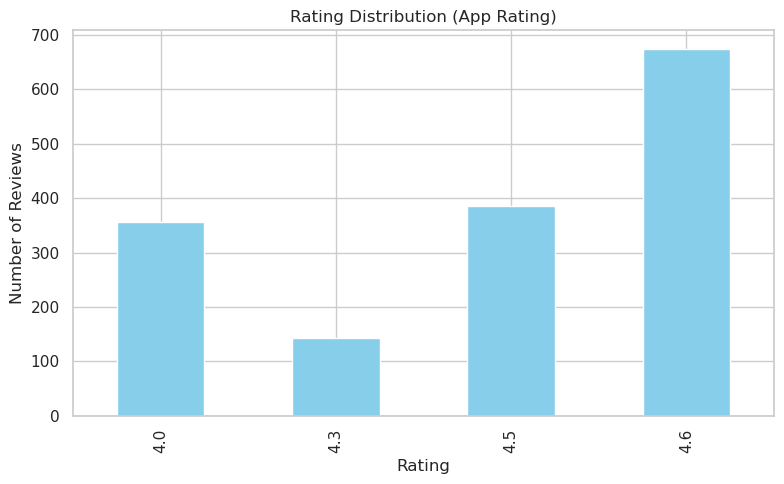

In [7]:
#1. Rating Distribution: bar chart count of reviews per rating
plt.figure()
rating_counts.plot(kind="bar", color="skyblue")
plt.title("Rating Distribution (App Rating)")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("figures_M1/Rating_Distribution.png", dpi=300)
plt.show()
plt.close()

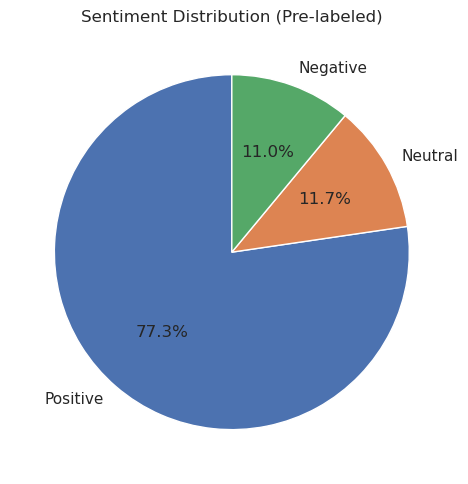

In [8]:
# 2. Sentiment Distribution (pre-labeled): pie chart
plt.figure()
sentiment_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Sentiment Distribution (Pre-labeled)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("figures_M1/Sentiment_Distribution.png", dpi=300)
plt.show()
plt.close()

<Figure size 800x500 with 0 Axes>

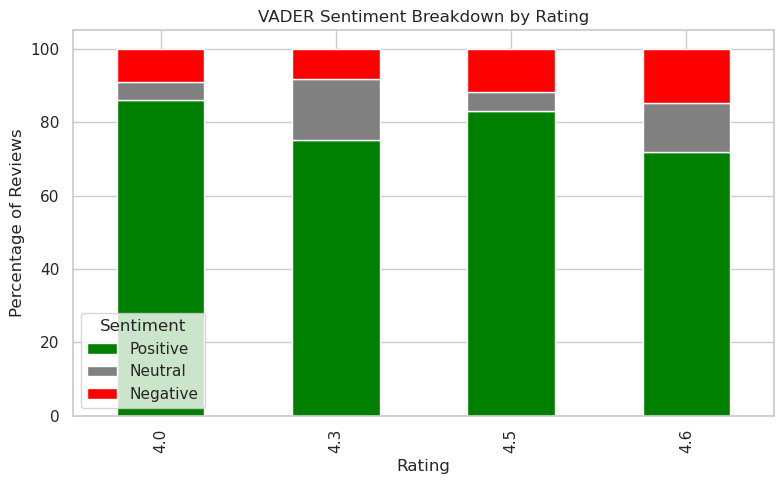

In [9]:
# 3. Sentiment by Rating: stacked bar chart of VADER sentiment breakdown per rating
sent_by_rating = pd.crosstab(df_desc["Rating"], df_desc["Sentiment_VADER"], normalize="index") * 100
# ensure consistent order if columns exist
for col in ["Positive", "Neutral", "Negative"]:
    if col not in sent_by_rating.columns:
        sent_by_rating[col] = 0.0
sent_by_rating = sent_by_rating[["Positive", "Neutral", "Negative"]]

plt.figure()
sent_by_rating.plot(kind="bar", stacked=True, color=["green", "gray", "red"])
plt.title("VADER Sentiment Breakdown by Rating")
plt.xlabel("Rating")
plt.ylabel("Percentage of Reviews")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("figures_M1/Sentiment_by_Rating_VADER.png", dpi=300)
plt.show()
plt.close()


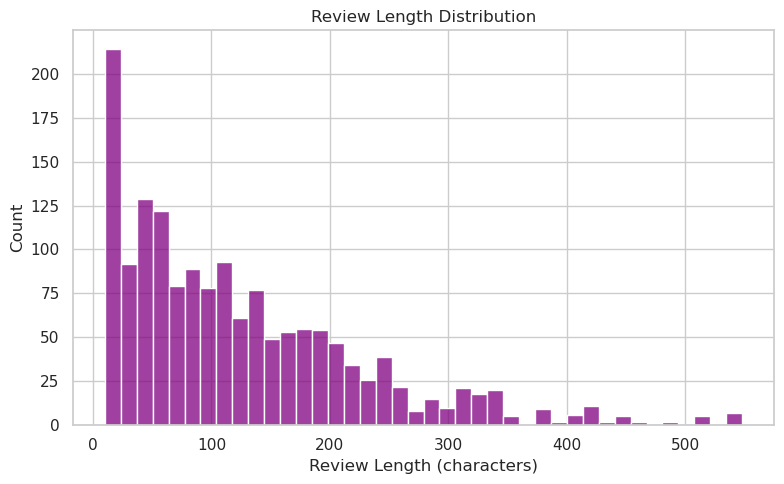

In [10]:
# 4. Review Length Distribution: histogram
plt.figure()
sns.histplot(df_desc["Review_Length"], bins=40, kde=False, color="purple")
plt.title("Review Length Distribution")
plt.xlabel("Review Length (characters)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures_M1/Review_Length_Distribution.png", dpi=300)
plt.show()
plt.close()

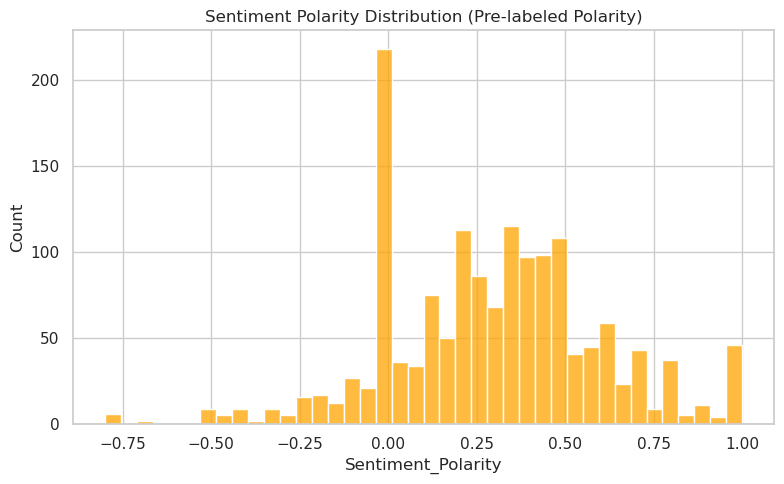

Saved and displayed all required M1 figures in ./figures_M1


In [11]:
# 5. Sentiment Polarity Distribution: histogram
plt.figure()
sns.histplot(df_desc["Sentiment_Polarity"], bins=40, kde=False, color="orange")
plt.title("Sentiment Polarity Distribution (Pre-labeled Polarity)")
plt.xlabel("Sentiment_Polarity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures_M1/Sentiment_Polarity_Distribution.png", dpi=300)
plt.show()
plt.close()

print("Saved and displayed all required M1 figures in ./figures_M1")

<Figure size 900x500 with 0 Axes>

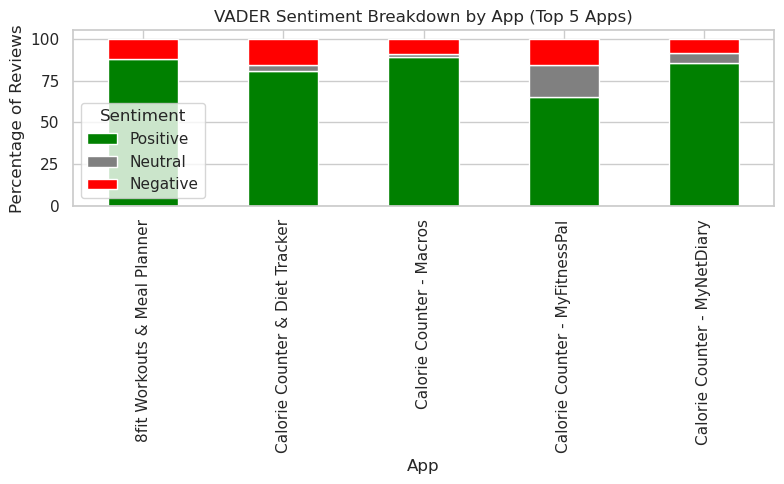

In [12]:
# 6. Sentiment by App (top 5 apps): stacked bar (Positive/Neutral/Negative %)
top5_app_names = (
    df_desc.groupby("App")["Translated_Review"]
    .count()
    .reset_index(name="Review_Count")
    .sort_values("Review_Count", ascending=False)
    .head(5)["App"]
    .tolist()
)

df_top5 = df_desc[df_desc["App"].isin(top5_app_names)].copy()
sent_by_app = (
    pd.crosstab(df_top5["App"], df_top5["Sentiment_VADER"], normalize="index") * 100
)

for col in ["Positive", "Neutral", "Negative"]:
    if col not in sent_by_app.columns:
        sent_by_app[col] = 0.0
sent_by_app = sent_by_app[["Positive", "Neutral", "Negative"]]

plt.figure(figsize=(9, 5))
sent_by_app.plot(kind="bar", stacked=True, color=["green", "gray", "red"])
plt.title("VADER Sentiment Breakdown by App (Top 5 Apps)")
plt.xlabel("App")
plt.ylabel("Percentage of Reviews")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("figures_M1/Sentiment_by_App_Top5.png", dpi=300)
plt.show()
plt.close()

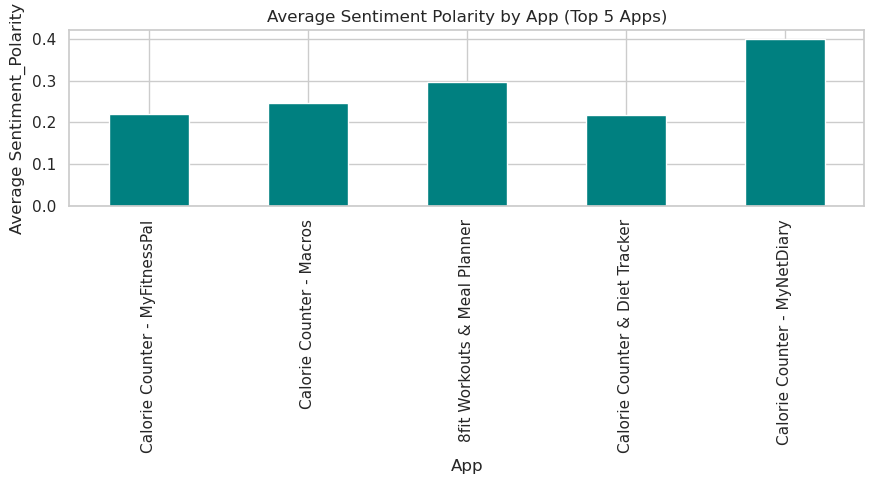

Saved and displayed charts 6, 7, and 8 in ./figures_M1


In [13]:
# 8. Average Sentiment Polarity by App (Top 5): bar chart
avg_polarity_app = (
    df_top5.groupby("App")["Sentiment_Polarity"]
    .mean()
    .reindex(top5_app_names)
)

plt.figure(figsize=(9, 5))
avg_polarity_app.plot(kind="bar", color="teal")
plt.title("Average Sentiment Polarity by App (Top 5 Apps)")
plt.xlabel("App")
plt.ylabel("Average Sentiment_Polarity")
plt.tight_layout()
plt.savefig("figures_M1/Avg_Polarity_by_App_Top5.png", dpi=300)
plt.show()
plt.close()

print("Saved and displayed charts 6, 7, and 8 in ./figures_M1")

In [14]:
# STEP 8: SAVE FINAL DATA FOR M2 & SUMMARY CSV

# Save enriched review dataset with VADER outputs for M2
cols_for_m2 = [
    "App",
    "Translated_Review",
    "Sentiment",
    "Sentiment_Polarity",
    "Sentiment_Subjectivity",
    "Review_Length",
    "Rating",
    "VADER_Compound",
    "Sentiment_VADER",
]
df_desc[cols_for_m2].to_csv("M1_Reviews_Enriched_For_M2.csv", index=False)
print("Saved: M1_Reviews_Enriched_For_M2.csv")

# Optional: basic summary stats table for quick reference in report
summary = {
    "Total_Apps": [len(selected_app_names)],
    "Total_Clean_Reviews": [df_desc.shape[0]],
    "Average_Rating": [avg_rating],
    "Positive_PreLabeled_%": [sentiment_pct.get("Positive", np.nan)],
    "Negative_PreLabeled_%": [sentiment_pct.get("Negative", np.nan)],
    "Neutral_PreLabeled_%": [sentiment_pct.get("Neutral", np.nan)],
    "VADER_Accuracy_vs_PreLabeled_%": [accuracy],
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv("M1_Summary_Stats.csv", index=False)
print("Saved: M1_Summary_Stats.csv")


Saved: M1_Reviews_Enriched_For_M2.csv
Saved: M1_Summary_Stats.csv
